In [1]:
pip install nibabel pandas numpy scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Walk up from wherever this kernel's cwd happens to be until we find the repo root.

    Needed because every relative path in this notebook ("validation/datasets/...")
    assumes cwd = repo root, but different tools (Jupyter, PyCharm, VS Code, or a
    plain `jupyter nbconvert --execute`) each default the kernel's starting
    directory differently - often to the notebook's own folder instead.
    """
    for parent in [start, *start.parents]:
        if (parent / "requirements.txt").exists() and (parent / "validation").is_dir():
            return parent
    raise FileNotFoundError(
        f"Could not locate the repo root by walking up from {start}. "
        "Expected a directory containing both requirements.txt and validation/."
    )


REPO_ROOT = _find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
print("Working directory set to:", Path.cwd())

Working directory set to: /Users/ziyuanch/Desktop/gradSchool/research/conferences/neurohack/multi_agent_decision_support_system


In [3]:
from pathlib import Path
import nibabel as nib
import numpy as np

mask_path = Path(
    "validation/datasets/NUMERACY_STROKE/"
    "data/raw/ds006533/derivatives/lesion_masks/"
    "sub-001/anat/sub-001_lesion-mask.nii.gz"
)

img = nib.load(mask_path)
data = np.asarray(img.dataobj)

print("Shape:", data.shape)
print("Data type:", data.dtype)
print("Voxel sizes in mm:", img.header.get_zooms()[:3])
print("Minimum:", np.nanmin(data))
print("Maximum:", np.nanmax(data))
print("Unique values:", np.unique(data)[:20])
print("Affine:")
print(img.affine)

Shape: (181, 217, 181)
Data type: float32
Voxel sizes in mm: (1.0, 1.0, 1.0)
Minimum: 0.0
Maximum: 1.0
Unique values: [0. 1.]
Affine:
[[  -1.   -0.   -0.   90.]
 [  -0.    1.   -0. -126.]
 [   0.    0.    1.  -72.]
 [   0.    0.    0.    1.]]


In [4]:
import json

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150       # higher-resolution inline rendering
plt.rcParams["savefig.dpi"] = 300      # higher-resolution if you ever save a figure

processed_dir = Path("validation/datasets/NUMERACY_STROKE/data/processed")
df = pd.read_csv(processed_dir / "_all_subjects_features.csv")
with open(processed_dir / "_feature_specs.json") as f:
    specs = json.load(f)

lesion_ratio_cols = [c for c in df.columns if c.startswith("lesion_ratio_p")]
print(f"Loaded {len(df)} subjects, {df.shape[1]} columns ({len(lesion_ratio_cols)} lesion ROI features)")

summary_cols = ["age", "education_years", "aphasia_quotient", "lesion_volume",
                "approximate_numeracy", "precise_numeracy"]
df[summary_cols].describe()

Loaded 105 subjects, 1182 columns (1168 lesion ROI features)


,age,education_years,aphasia_quotient,lesion_volume,approximate_numeracy,precise_numeracy
count,105.000000,105.00000,105.000000,105.000000,1.040000e+02,104.000000
mean,61.561905,15.07619,93.077764,0.044060,-2.932692e-09,-0.000626
std,12.071839,2.70219,12.133425,0.081193,1.000000e+00,0.674952
min,25.000000,9.00000,24.621053,0.000146,-3.605475e+00,-3.846778
25%,56.000000,13.00000,92.800000,0.001356,-3.180242e-01,-0.096583
50%,62.000000,14.00000,96.800000,0.008057,1.607307e-01,0.153359
75%,71.000000,16.00000,98.977778,0.043977,6.394856e-01,0.403125
max,82.000000,22.00000,100.000000,0.427203,1.373576e+00,0.403125


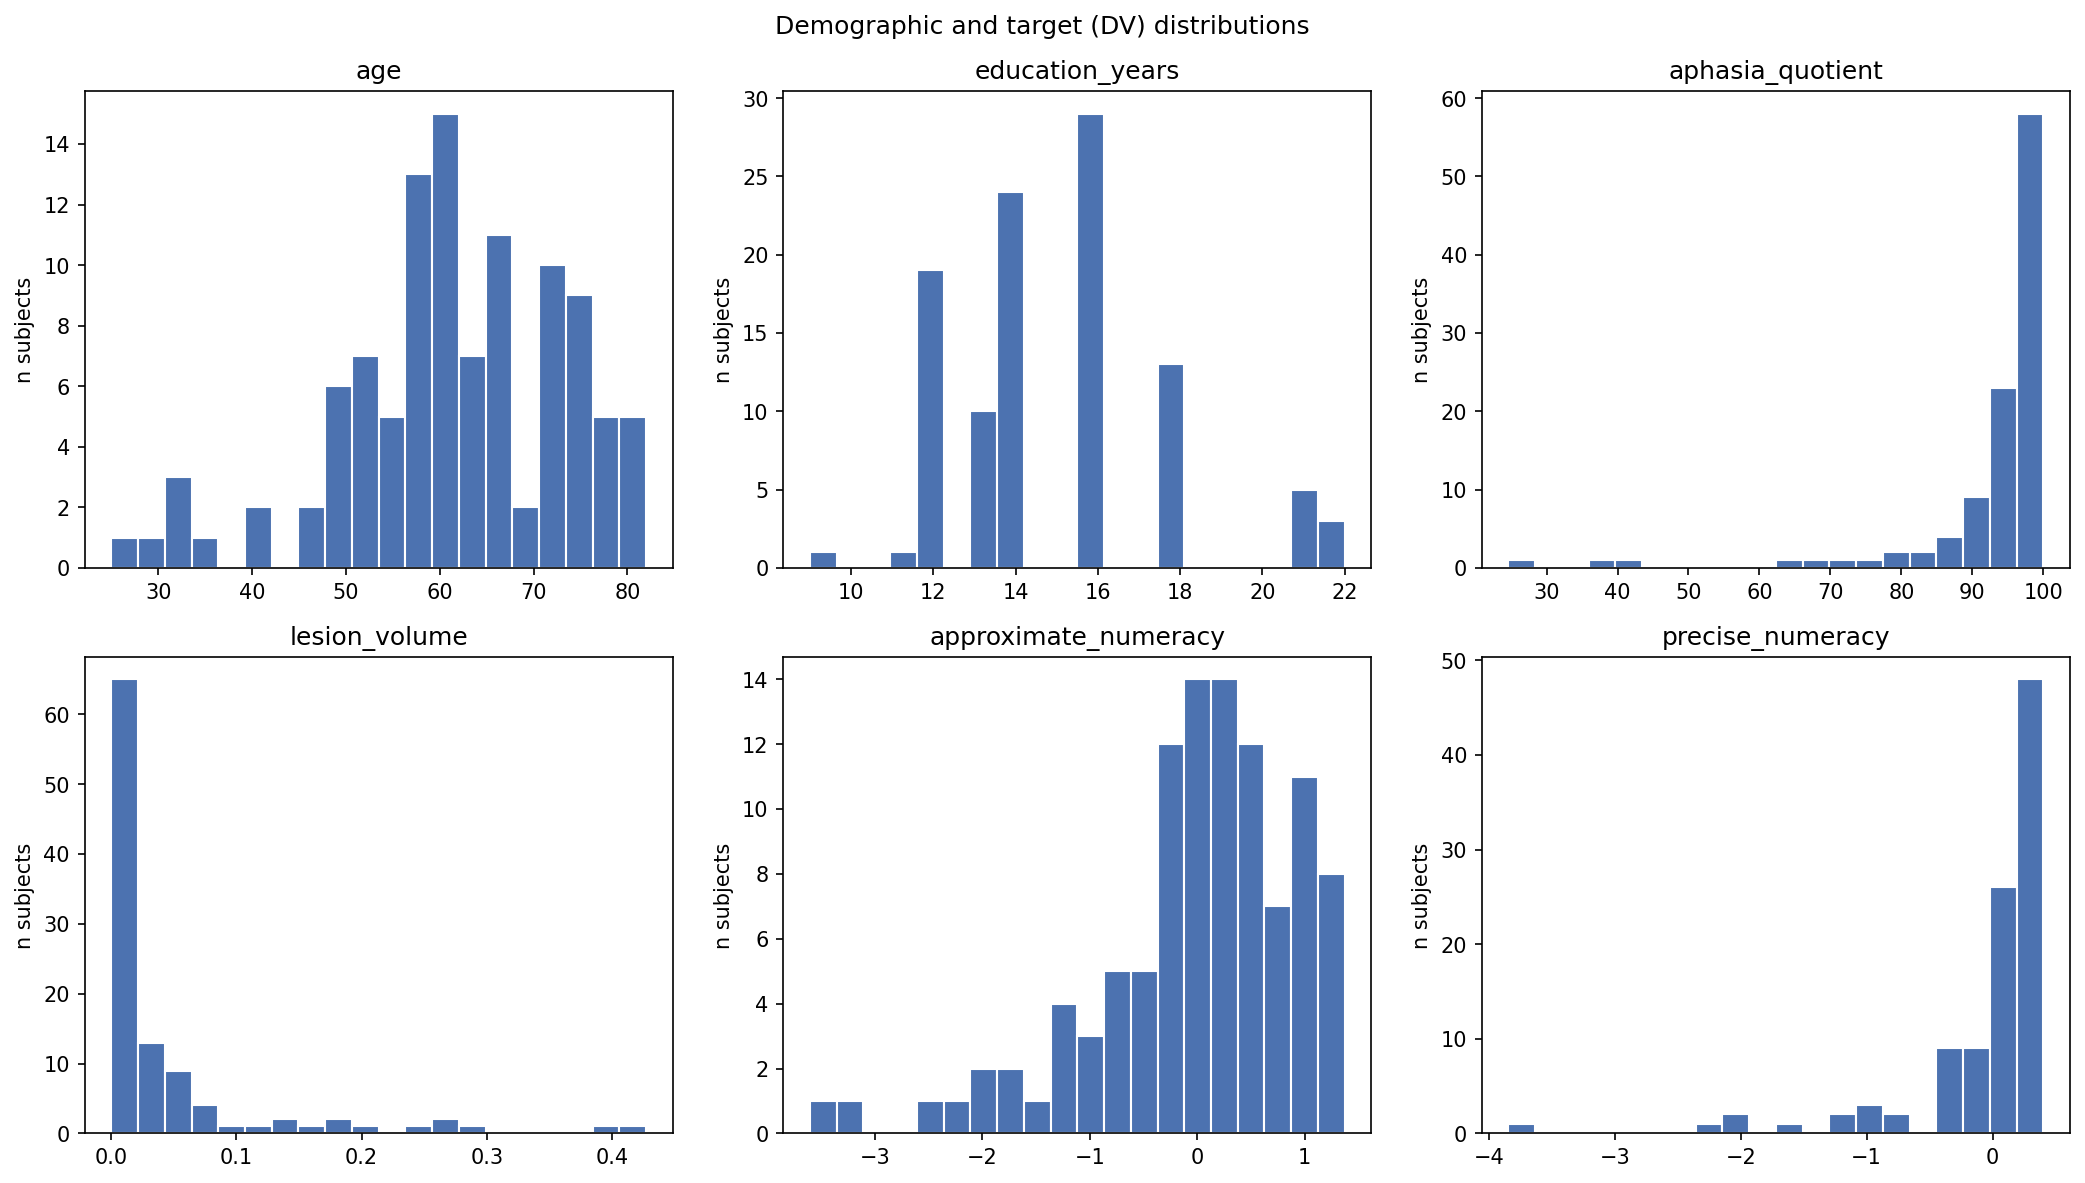

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, summary_cols):
    ax.hist(df[col].dropna(), bins=20, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("n subjects")
fig.suptitle("Demographic and target (DV) distributions")
plt.tight_layout()
plt.show()

Affected ROI count per subject (out of 1168 total ROIs):
count    105.000000
mean      45.352381
std       62.079661
min        0.000000
25%        4.000000
50%       13.000000
75%       66.000000
max      308.000000
dtype: float64


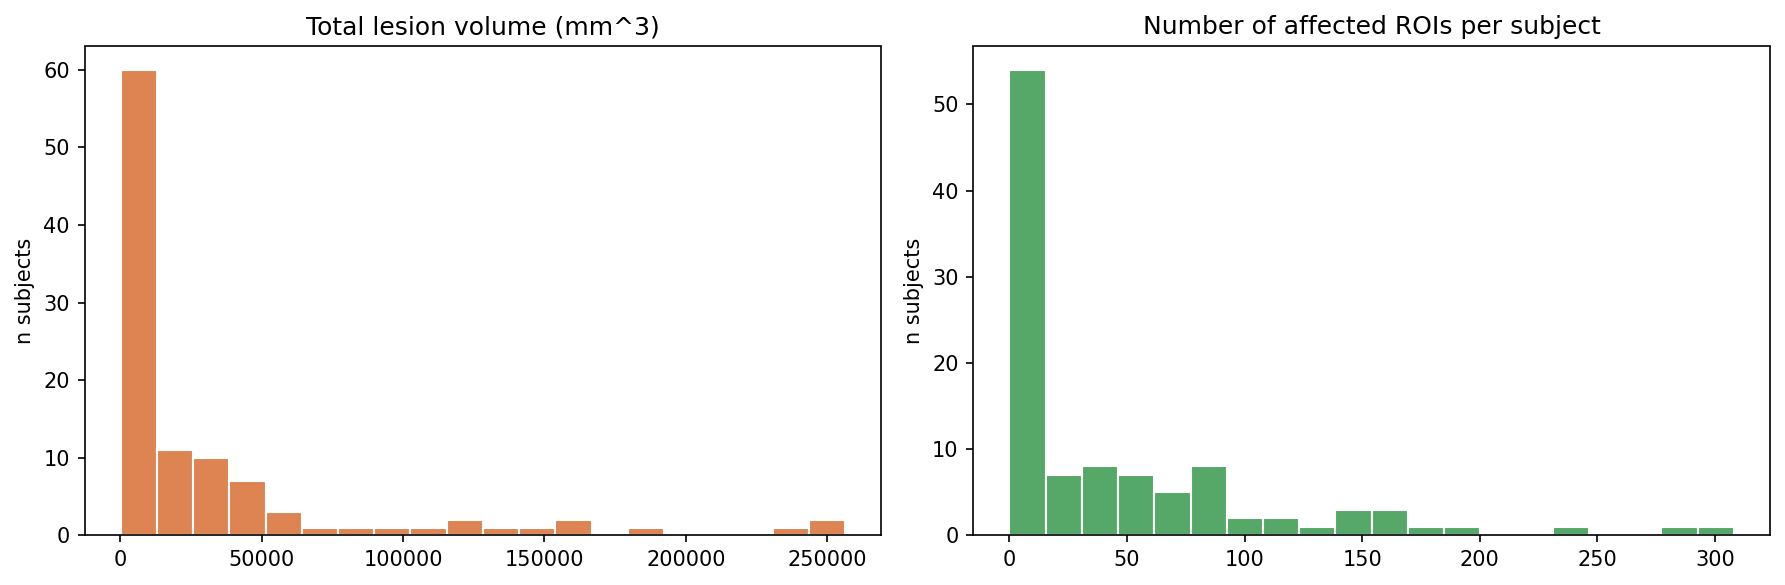

In [6]:
n_affected_rois = (df[lesion_ratio_cols] > 0).sum(axis=1)
print("Affected ROI count per subject (out of", len(lesion_ratio_cols), "total ROIs):")
print(n_affected_rois.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["lesion_total_volume_mm3"], bins=20, color="#DD8452", edgecolor="white")
axes[0].set_title("Total lesion volume (mm^3)")
axes[0].set_ylabel("n subjects")
axes[1].hist(n_affected_rois, bins=20, color="#55A868", edgecolor="white")
axes[1].set_title("Number of affected ROIs per subject")
axes[1].set_ylabel("n subjects")
plt.tight_layout()
plt.show()

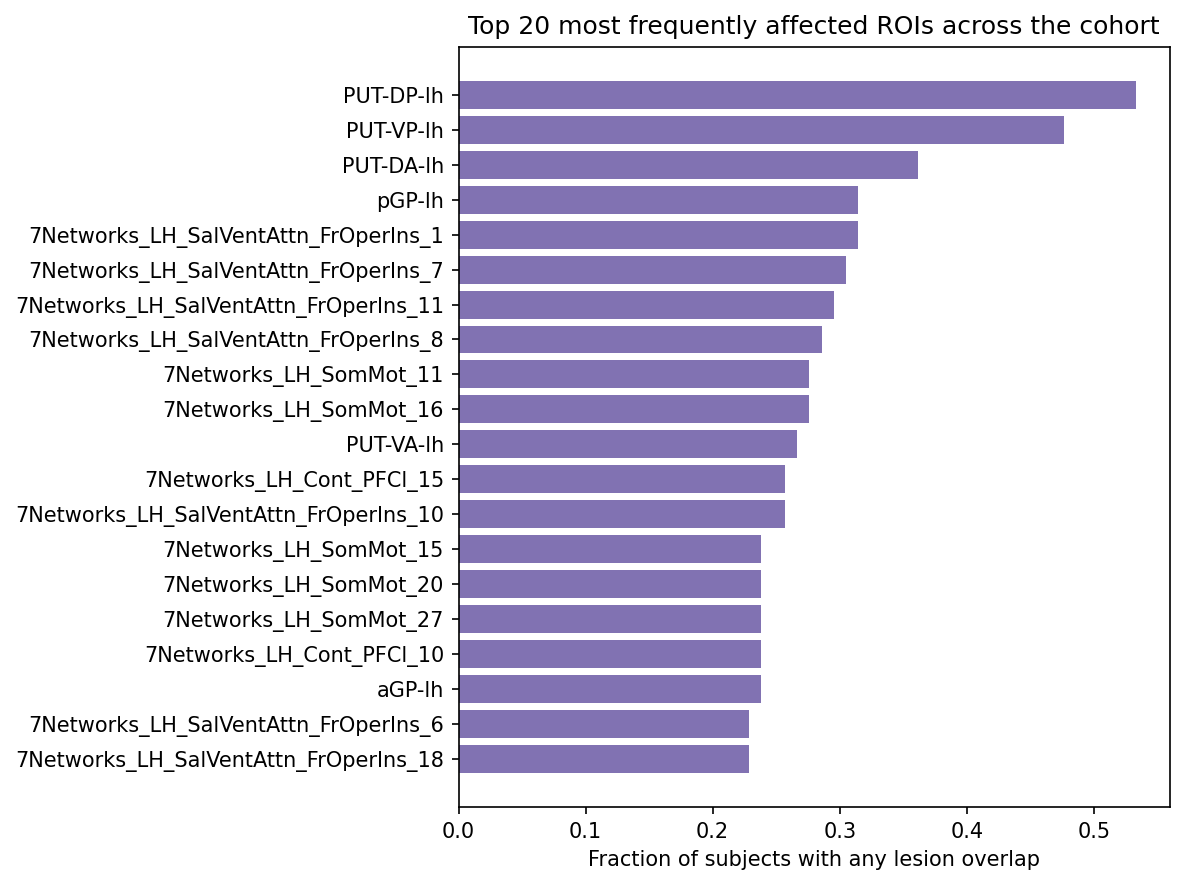

In [7]:
affected_frac = (df[lesion_ratio_cols] > 0).mean(axis=0).sort_values(ascending=False)
top20 = affected_frac.head(20)
labels = [specs[c]["label"].replace("Lesion overlap: ", "") for c in top20.index]

plt.figure(figsize=(8, 6))
plt.barh(labels[::-1], top20.values[::-1], color="#8172B2")
plt.xlabel("Fraction of subjects with any lesion overlap")
plt.title("Top 20 most frequently affected ROIs across the cohort")
plt.tight_layout()
plt.show()

## Mean-centered vs. z-scored variables

Two related but different rescalings, both computed per-column across this
105-subject cohort:

1. **Mean-centered**: `x_centered = x - mean(x)`. Shifts the distribution so
   it's centered on 0, but keeps the original units and spread (std) untouched.
   Useful mainly so an intercept/bias term is interpretable at the "average
   subject" rather than at x=0 (e.g. age=0 is meaningless; age=mean is not).
2. **Z-scored (standardized)**: `z = (x - mean(x)) / std(x)`. Same centering,
   but also rescales so every variable has std=1. This is what actually makes
   variables **comparable** — `age` (range ~25-82) and `lesion_volume` (range
   ~0.0001-0.43) live on wildly different scales, so raw regression
   coefficients or distances between them aren't comparable until standardized.

**If you decide to feed z-scored variables into your prediction pipeline:**
- Compute mean/std **only on the training split**, then apply that same
  mean/std to transform the validation/test split (never refit on test data —
  that leaks information about the held-out set into the model).
- Do this separately for every feature column (demographics, lesion ROI
  ratios, etc.) — each has its own mean/std.
- The two DVs (`approximate_numeracy`, `precise_numeracy`) are *already*
  z-scored in this dataset (per the BIDS docs: "Z-score of performance..."),
  which is why `approximate_numeracy`'s mean/std above are ~0/~1 already —
  no need to re-standardize the targets yourselves.
- Binary/categorical columns (e.g. `image_modality`) should **not** be
  z-scored — standardization only makes sense for continuous numeric
  features.
- Store the training mean/std somewhere (e.g. alongside the model) so new
  subjects at inference time get transformed consistently.

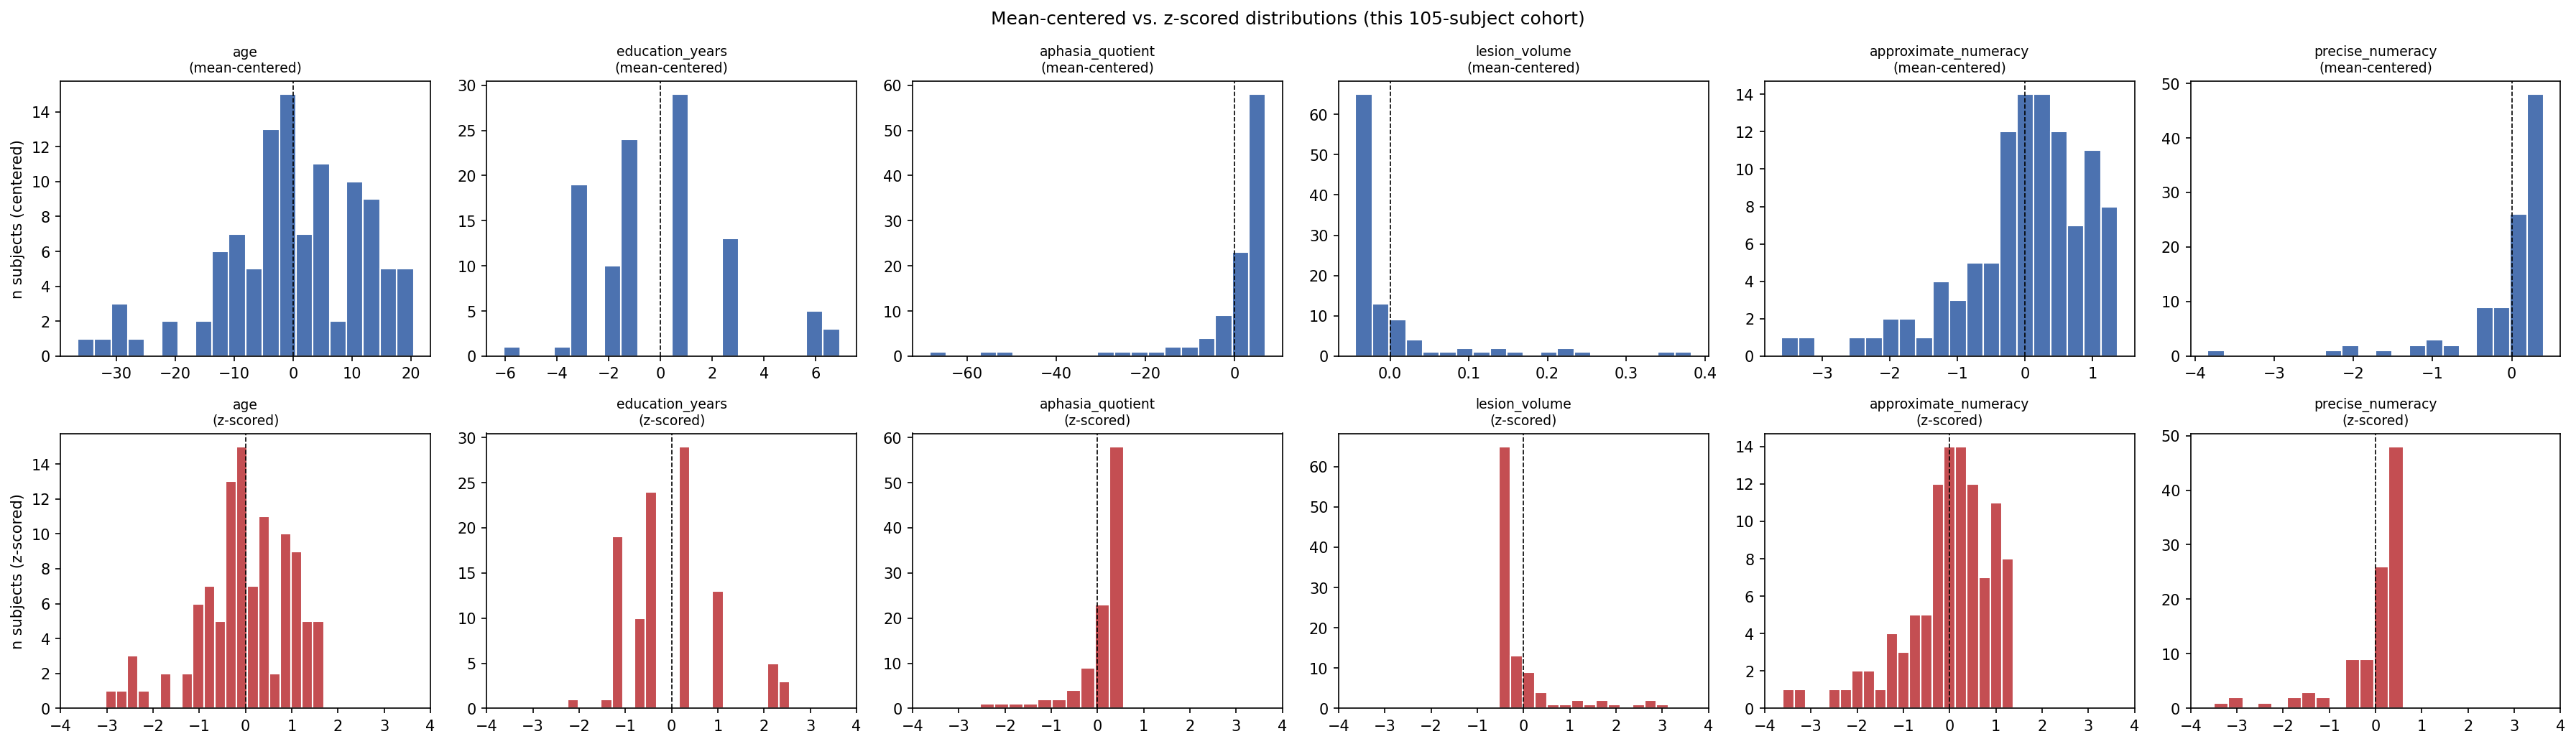

Per-column mean / std used for the z-score above:
                              mean        std
age                   6.156190e+01  12.071839
education_years       1.507619e+01   2.702190
aphasia_quotient      9.307776e+01  12.133425
lesion_volume         4.405993e-02   0.081193
approximate_numeracy -2.932692e-09   1.000000
precise_numeracy     -6.256366e-04   0.674952


In [8]:
centered = df[summary_cols] - df[summary_cols].mean()
zscored = centered / df[summary_cols].std()

fig, axes = plt.subplots(2, len(summary_cols), figsize=(4 * len(summary_cols), 7))
for col_idx, col in enumerate(summary_cols):
    ax_c, ax_z = axes[0, col_idx], axes[1, col_idx]
    ax_c.hist(centered[col].dropna(), bins=20, color="#4C72B0", edgecolor="white")
    ax_c.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax_c.set_title(f"{col}\n(mean-centered)", fontsize=9)

    ax_z.hist(zscored[col].dropna(), bins=20, color="#C44E52", edgecolor="white")
    ax_z.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax_z.set_title(f"{col}\n(z-scored)", fontsize=9)
    ax_z.set_xlim(-4, 4)

axes[0, 0].set_ylabel("n subjects (centered)")
axes[1, 0].set_ylabel("n subjects (z-scored)")
fig.suptitle("Mean-centered vs. z-scored distributions (this 105-subject cohort)")
plt.tight_layout()
plt.show()

print("Per-column mean / std used for the z-score above:")
print(df[summary_cols].agg(["mean", "std"]).T)

## `aphasia_quotient` and `precise_numeracy` are still skewed after z-scoring

Z-scoring only shifts/rescales a distribution — it cannot fix its *shape*.
Both variables have a **ceiling effect** (most stroke survivors score near
the top of the scale, with a long tail of more-impaired subjects trailing
below), which shows up as skew no matter how you rescale it. Below are a few
shape-changing transforms, compared by skewness (0 = symmetric):

In [9]:
import sys
sys.path.insert(0, ".")  # repo root, so validation.common is importable

from scipy import stats
from validation.common.transforms import rank_int

transform_results = {}
for col in ["aphasia_quotient", "precise_numeracy"]:
    x = df[col].dropna()
    raw_skew = stats.skew(x)
    yj, _ = stats.yeojohnson(x)
    rint = rank_int(x)
    # reflect (ceiling -> floor) + Box-Cox, since both variables have a ceiling effect
    shifted = x.max() + 1 - x
    reflect_bc, lam = stats.boxcox(shifted)

    transform_results[col] = {
        "raw / z-scored (same skew)": raw_skew,
        "Yeo-Johnson": stats.skew(yj),
        "rank-based inverse normal": stats.skew(rint),
        f"reflect + Box-Cox (lambda={lam:.2f})": stats.skew(reflect_bc),
    }

results_df = pd.DataFrame(transform_results).round(3)
print("Skewness by transform (closer to 0 = more symmetric):")
results_df

Skewness by transform (closer to 0 = more symmetric):


,aphasia_quotient,precise_numeracy
raw / z-scored (same skew),-3.669,-2.951
Yeo-Johnson,-0.937,-0.454
rank-based inverse normal,-0.117,-0.706
reflect + Box-Cox (lambda=-0.24),0.046,NaN
reflect + Box-Cox (lambda=-2.27),NaN,0.394


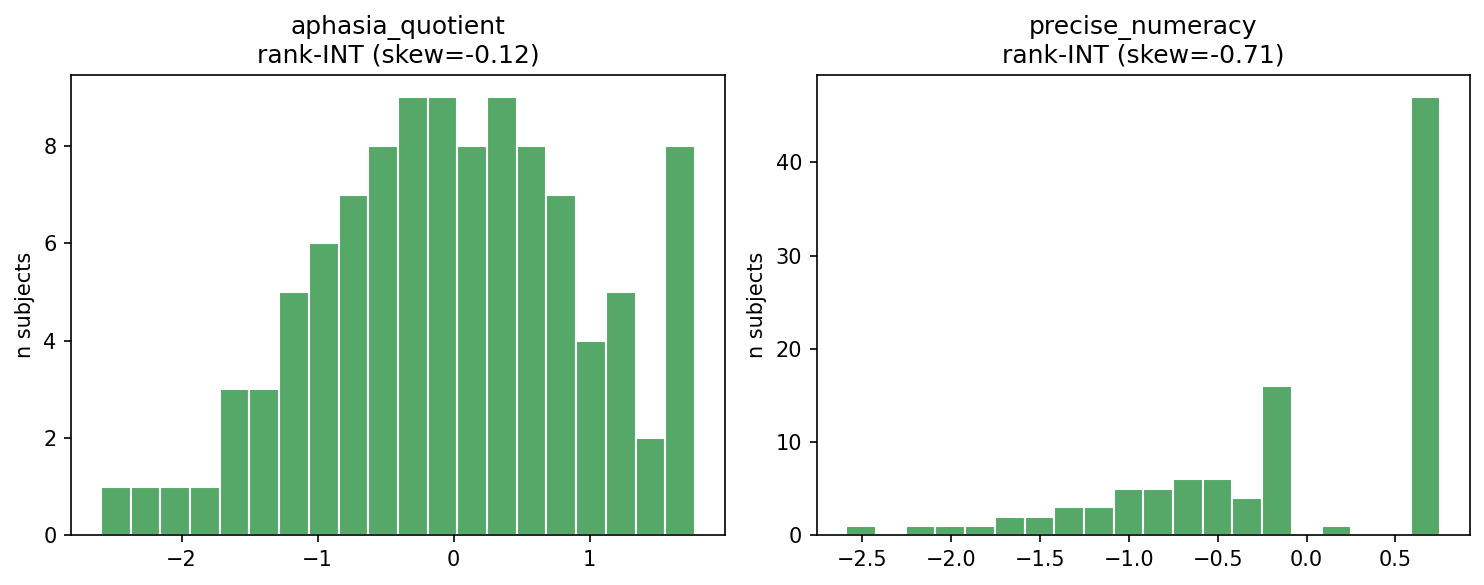

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["aphasia_quotient", "precise_numeracy"]):
    x = df[col].dropna()
    ax.hist(rank_int(x), bins=20, color="#55A868", edgecolor="white")
    ax.set_title(f"{col}\nrank-INT (skew={stats.skew(rank_int(x)):.2f})")
    ax.set_ylabel("n subjects")
plt.tight_layout()
plt.show()

**Recommendation**: rank-based inverse normal transform (rank-INT) for both —
it's distribution-free (no lambda to fit/store, no assumption about *why*
it's skewed), always produces an exactly-Gaussian result regardless of the
raw shape, and got `aphasia_quotient` to skew ≈ -0.12 and `precise_numeracy`
to skew ≈ -0.71 (a large improvement over the raw -3.67 / -2.95, though
`precise_numeracy` — a composite across 4 sub-tests — stays a bit skewed no
matter what; reflect+Box-Cox does slightly better there, 0.39, at the cost of
a fitted lambda you'd need to store and re-apply consistently). Whichever you
pick, see the note above on fitting it only on the training split.

## A closer look at `precise_numeracy`: more transforms, and why it resists all of them

`precise_numeracy` stayed the most skewed variable after every transform
above. Trying a wider sweep (reflect+log, reflect+sqrt, reflect+cube-root,
Box-Cox with larger shifts, winsorizing) to see if anything does
meaningfully better than Yeo-Johnson/rank-INT.

In [11]:
x = df["precise_numeracy"].dropna()
shifted = x.max() + 1 - x  # reflect: ceiling -> floor, needed for log/sqrt/cbrt/Box-Cox

sweep = {"raw / z-scored": stats.skew(x)}
sweep["reflect + log"] = stats.skew(np.log(shifted))
sweep["reflect + sqrt"] = stats.skew(np.sqrt(shifted))
sweep["reflect + cube-root"] = stats.skew(np.cbrt(shifted))
bc, lam = stats.boxcox(shifted)
sweep[f"reflect + Box-Cox (lambda={lam:.2f})"] = stats.skew(bc)

# larger shifts make the ceiling less extreme relative to the rest of the scale
for extra in (2, 5):
    shifted_extra = x.max() + extra - x
    bc_extra, lam_extra = stats.boxcox(shifted_extra)
    sweep[f"reflect(+{extra}) + Box-Cox (lambda={lam_extra:.2f})"] = stats.skew(bc_extra)

# winsorizing (clip extreme values) softens outliers but doesn't reshape a distribution
z = (x - x.mean()) / x.std()
sweep["winsorize |z|<=3 (no reshaping)"] = stats.skew(z.clip(-3, 3))

sweep["Yeo-Johnson"] = stats.skew(stats.yeojohnson(x)[0])
sweep["rank-based inverse normal"] = stats.skew(rank_int(x))

for name, skew in sorted(sweep.items(), key=lambda kv: abs(kv[1])):
    print(f"{name:42s} skew={skew:+.3f}")

n_at_ceiling = (x == x.max()).sum()
print(f"\n{n_at_ceiling}/{len(x)} subjects ({100*n_at_ceiling/len(x):.0f}%) "
      f"tie exactly at the max value ({x.max():.4f}).")

reflect + Box-Cox (lambda=-2.27)           skew=+0.394
Yeo-Johnson                                skew=-0.454
reflect(+2) + Box-Cox (lambda=-4.10)       skew=+0.458
reflect(+5) + Box-Cox (lambda=-9.31)       skew=+0.523
rank-based inverse normal                  skew=-0.706
reflect + log                              skew=+1.637
reflect + cube-root                        skew=+1.997
winsorize |z|<=3 (no reshaping)            skew=-2.109
reflect + sqrt                             skew=+2.205
raw / z-scored                             skew=-2.951

47/104 subjects (45%) tie exactly at the max value (0.4031).


**Why nothing fully fixes it**: 47 of 104 subjects (45%!) tie at *exactly*
the same maximum value. That's not ordinary skew — it's a **point-mass at
ceiling** (this composite, built from 4 sub-tests, saturates for
nearly half the cohort). No monotonic transform can spread apart values that
are identically equal in the raw data; skew can be reduced but that big spike
at one value remains. Practical implications:
- Winsorizing barely moves the skew (-2.11) because the issue isn't a few
  extreme outliers, it's a mass of *tied* values — nothing to clip away.
- reflect+Box-Cox is the best pure skew number (0.38-0.39) but needs an
  extreme fitted lambda (≈ -2.3) to get there, which is a sign of overfitting
  to this exact sample rather than a stable, generalizable transform.
- **Final pick: Yeo-Johnson** (skew -0.45) — not the best number, but stable
  and consistent with the transform already used for `approximate_numeracy`.
  If you go this route, it may be worth treating "at ceiling vs. not" as an
  additional binary feature/consideration alongside whatever continuous
  transform you use, since the continuous transform can't fully represent
  that structure.

## Outlier check: does removing extreme subjects change the picture?

Flagging outliers as `|z-score| > 3` (a common convention — more than 3
standard deviations from the mean) on the **raw** values of each column, then
comparing raw and rank-INT-transformed distributions with those subjects
dropped vs. kept. This tells you whether the skew above is being driven by a
handful of extreme subjects or is a genuine property of the whole
distribution.

aphasia_quotient: 3 outlier(s) -> ['sub-053', 'sub-084', 'sub-102']
precise_numeracy: 3 outlier(s) -> ['sub-006', 'sub-053', 'sub-102']


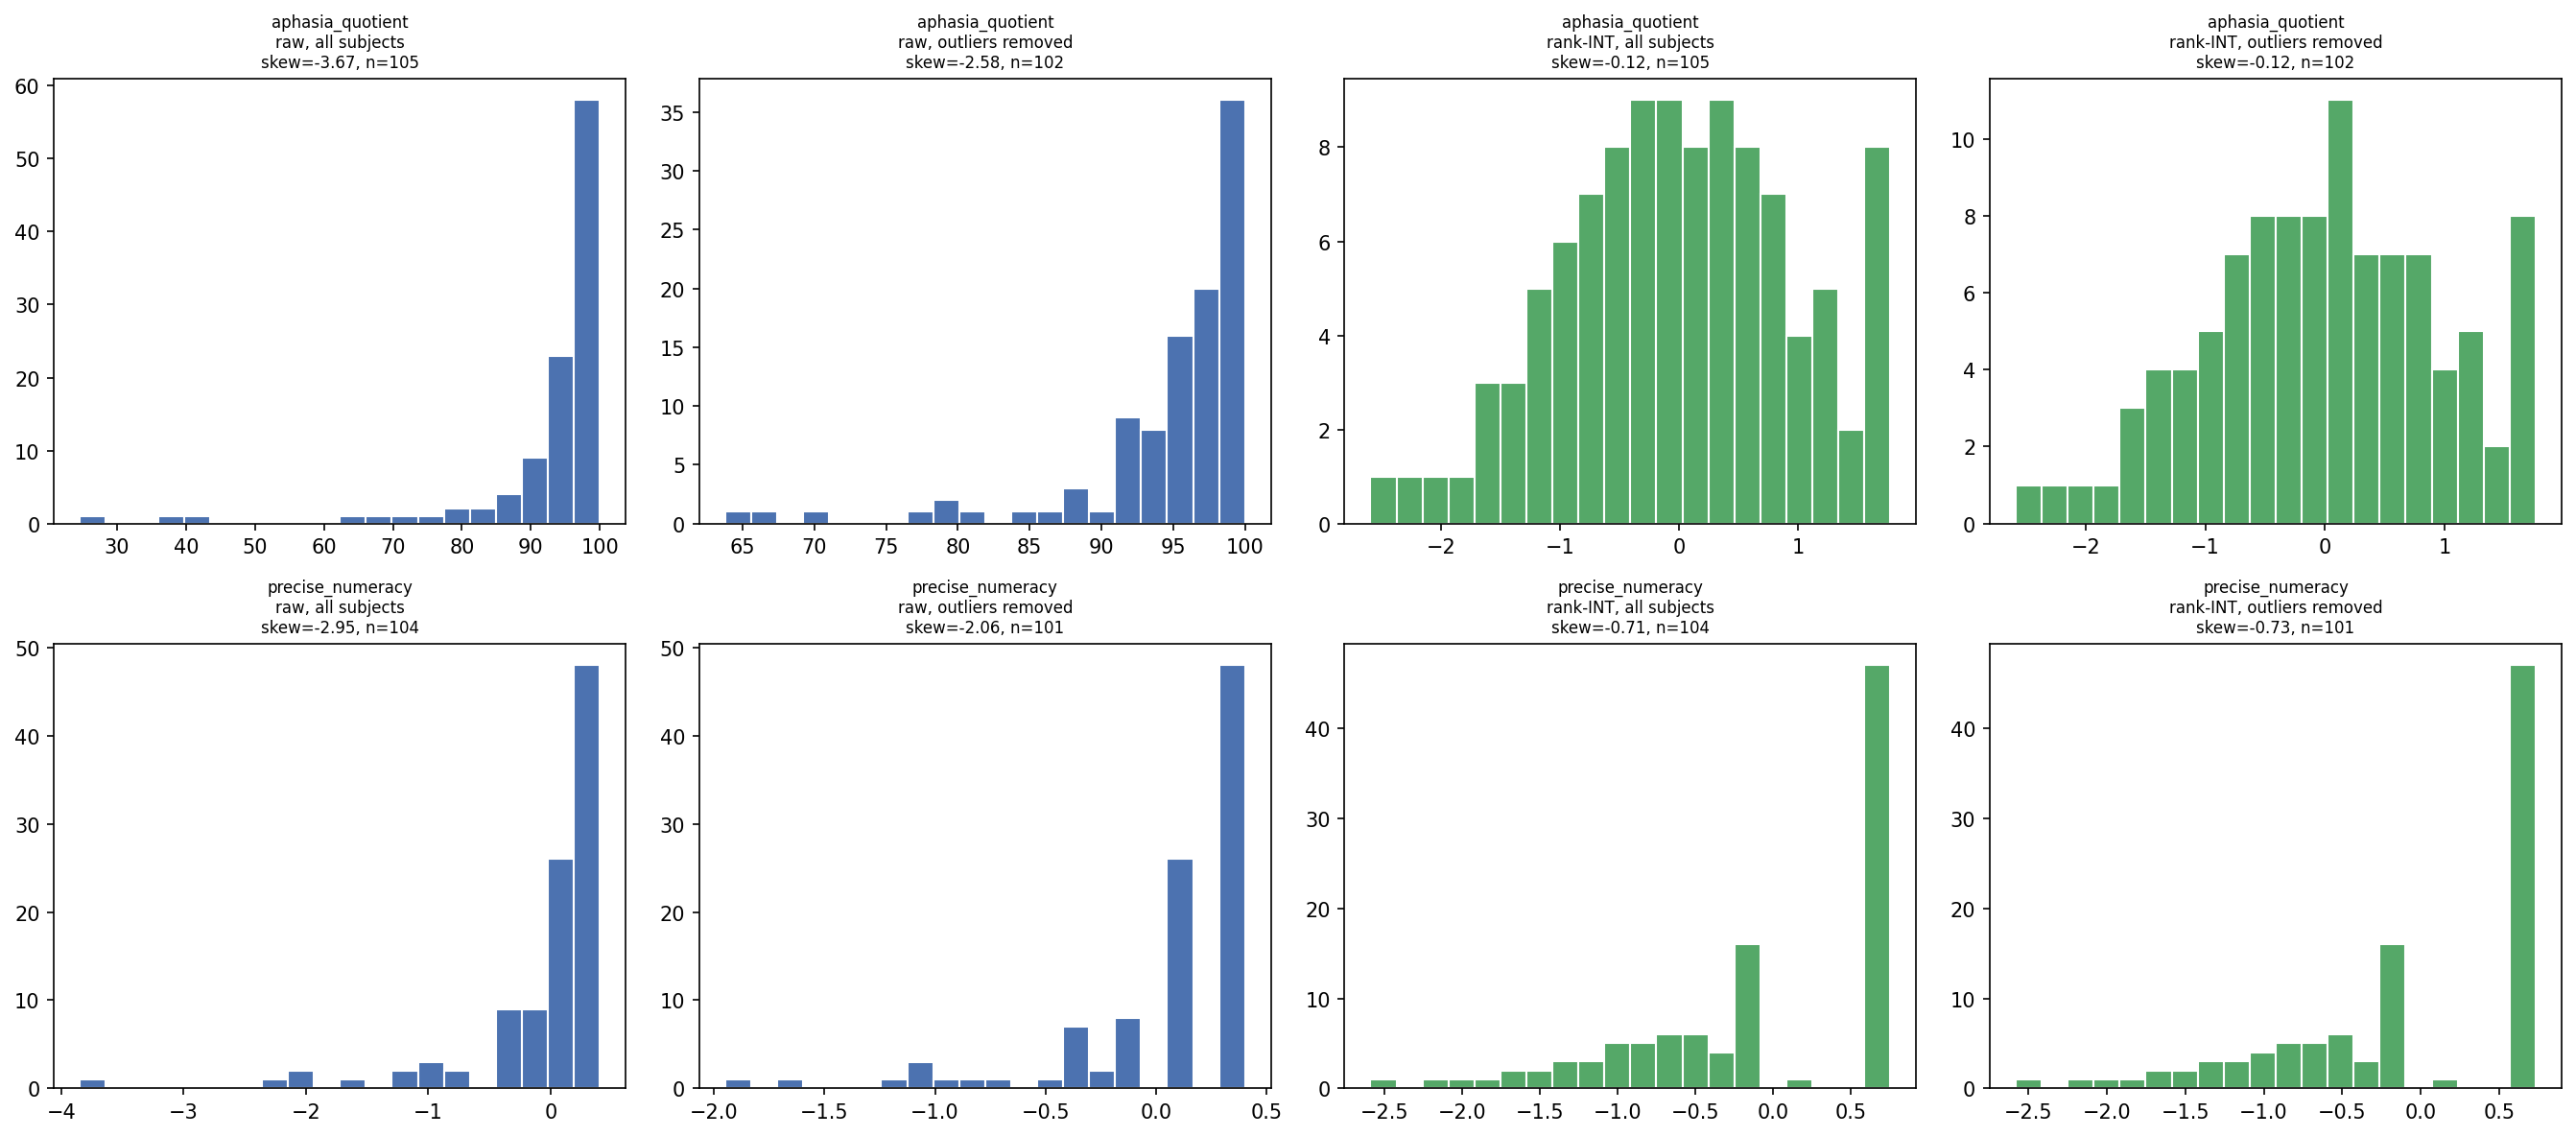

In [12]:
from validation.common.transforms import flag_outliers_zscore

outlier_cols = ["aphasia_quotient", "precise_numeracy"]
fig, axes = plt.subplots(len(outlier_cols), 4, figsize=(18, 4 * len(outlier_cols)))

for row, col in enumerate(outlier_cols):
    x = df[["participant_id", col]].dropna().set_index("participant_id")[col]
    is_outlier = flag_outliers_zscore(x)
    print(f"{col}: {is_outlier.sum()} outlier(s) -> {x.index[is_outlier].tolist()}")
    x_kept = x[~is_outlier]

    for j, (label, values) in enumerate([
        ("raw, all subjects", x),
        ("raw, outliers removed", x_kept),
        ("rank-INT, all subjects", pd.Series(rank_int(x), index=x.index)),
        ("rank-INT, outliers removed", pd.Series(rank_int(x_kept), index=x_kept.index)),
    ]):
        ax = axes[row, j]
        color = "#4C72B0" if "raw" in label else "#55A868"
        ax.hist(values, bins=20, color=color, edgecolor="white")
        ax.set_title(f"{col}\n{label}\nskew={stats.skew(values):.2f}, n={len(values)}", fontsize=8)

plt.tight_layout()
plt.show()

## Transformations for `approximate_numeracy` and `lesion_volume`

`lesion_volume` (from `participants.tsv`) is the dataset authors' own
whole-brain summary: **the proportion of the left hemisphere that is
lesioned** (0-1 scale; e.g. 0.27 = 27% of the left hemisphere is damaged).
It's the same quantity our `lesion_total_volume_mm3` cross-checks against,
just expressed as a hemisphere proportion instead of raw mm³, and computed by
the original authors rather than by our pipeline.

Shape-wise, `lesion_volume` and `approximate_numeracy` are different problems
from `aphasia_quotient`/`precise_numeracy`:
- `lesion_volume` is a proportion with a **floor at 0** and a long right tail
  (a few subjects have very large lesions) - no ceiling effect.
- `approximate_numeracy` has the same **ceiling-effect** shape as the other
  two DVs, just milder (raw skew -1.2 vs -3.7/-3.0).

In [13]:
results2 = {}

# approximate_numeracy: same ceiling shape as aphasia_quotient/precise_numeracy
x = df["approximate_numeracy"].dropna()
yj, _ = stats.yeojohnson(x)
shifted = x.max() + 1 - x
reflect_bc, lam = stats.boxcox(shifted)
results2["approximate_numeracy"] = {
    "raw / z-scored": stats.skew(x),
    "Yeo-Johnson": stats.skew(yj),
    "rank-based inverse normal": stats.skew(rank_int(x)),
    f"reflect + Box-Cox (lambda={lam:.2f})": stats.skew(reflect_bc),
}

# lesion_volume: floor at 0, right-skewed - no reflection needed, plain log/Box-Cox apply directly
x = df["lesion_volume"].dropna()
log_x = np.log(x)
bc, lam = stats.boxcox(x)
yj, _ = stats.yeojohnson(x)
results2["lesion_volume"] = {
    "raw": stats.skew(x),
    "log": stats.skew(log_x),
    f"Box-Cox (lambda={lam:.2f})": stats.skew(bc),
    "Yeo-Johnson": stats.skew(yj),
    "rank-based inverse normal": stats.skew(rank_int(x)),
}

for name, res in results2.items():
    print(f"\n{name}:")
    for k, v in res.items():
        print(f"  {k}: {v:.3f}")


approximate_numeracy:
  raw / z-scored: -1.196
  Yeo-Johnson: -0.043
  rank-based inverse normal: -0.073
  reflect + Box-Cox (lambda=-0.06): 0.002

lesion_volume:
  raw: 2.783
  log: -0.047
  Box-Cox (lambda=0.01): -0.009
  Yeo-Johnson: 0.805
  rank-based inverse normal: 0.000


**Recommendation**: `lesion_volume` cleans up almost perfectly with a plain
**log transform** (skew ≈ -0.05, vs. raw 2.78) — no need for anything fancier;
this is also the standard treatment for lesion volume in the literature.
`approximate_numeracy` responds well to any of the three (all get skew under
0.1); rank-INT again for consistency with the other DVs, or reflect+Box-Cox
if you want the single best number.

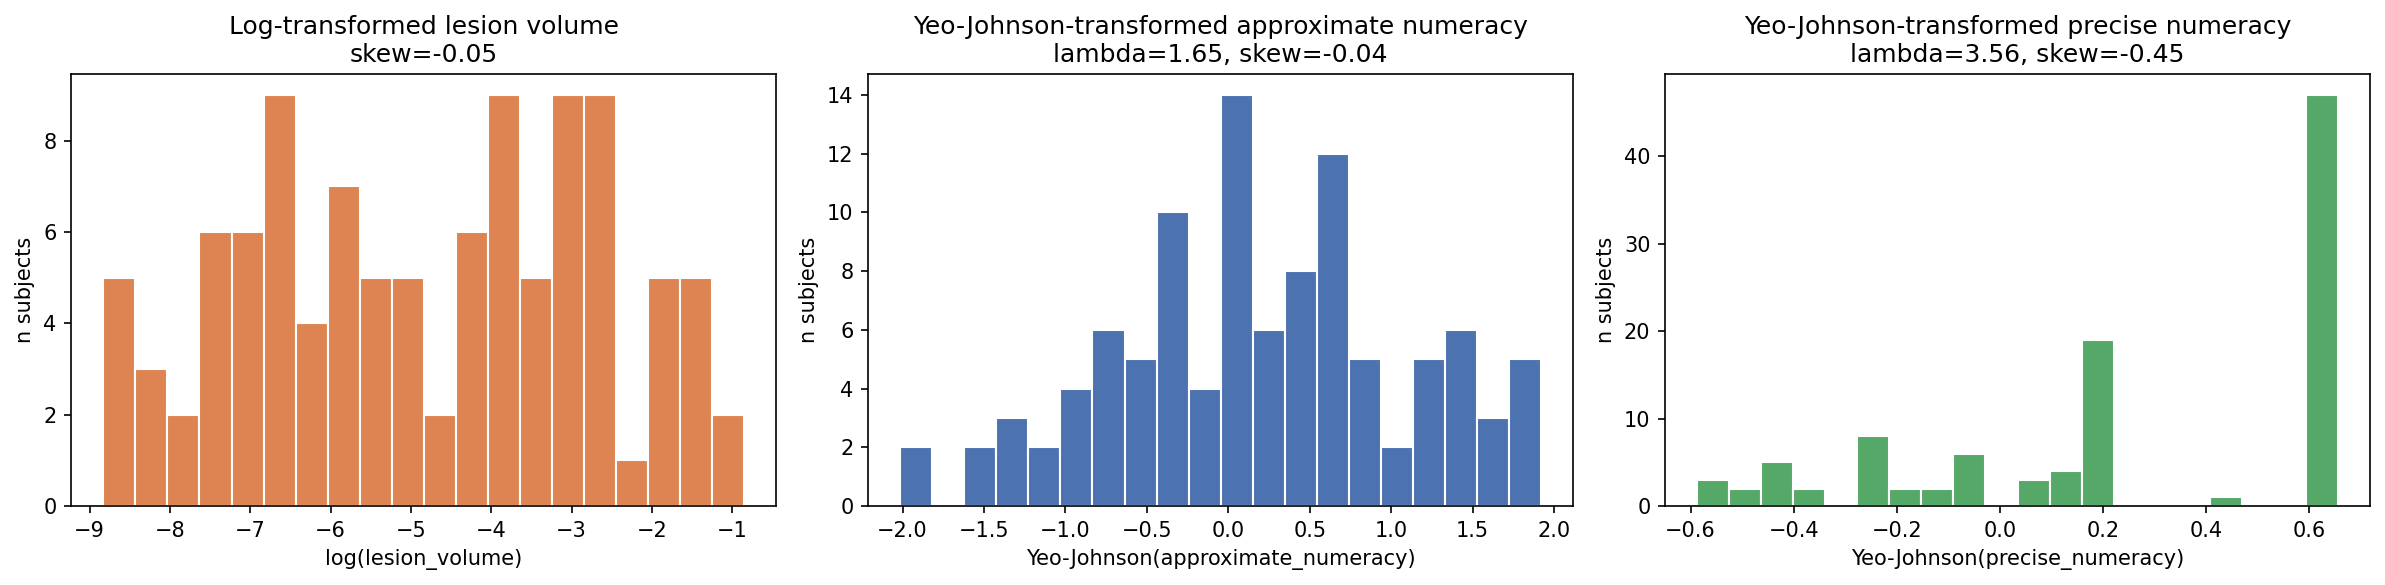

In [14]:
# Plot the recommended transforms
lesion = df["lesion_volume"].dropna()
if (lesion <= 0).any():
    raise ValueError(
        "lesion_volume contains zero or negative values, "
        "so np.log() is undefined."
    )

log_lesion_volume = np.log(lesion)

# Yeo-Johnson transform: approximate numeracy
approx = df["approximate_numeracy"].dropna()
yj_approximate_accuracy, yj_approx_lambda = stats.yeojohnson(approx)

# Yeo-Johnson transform: precise numeracy
precise = df["precise_numeracy"].dropna()
yj_precise_accuracy, yj_precise_lambda = stats.yeojohnson(precise)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(
    log_lesion_volume,
    bins=20,
    color="#DD8452",
    edgecolor="white"
)
axes[0].set_title(
    f"Log-transformed lesion volume\n"
    f"skew={stats.skew(log_lesion_volume):.2f}"
)
axes[0].set_xlabel("log(lesion_volume)")
axes[0].set_ylabel("n subjects")

axes[1].hist(
    yj_approximate_accuracy,
    bins=20,
    color="#4C72B0",
    edgecolor="white"
)
axes[1].set_title(
    f"Yeo-Johnson-transformed approximate numeracy\n"
    f"lambda={yj_approx_lambda:.2f}, "
    f"skew={stats.skew(yj_approximate_accuracy):.2f}"
)
axes[1].set_xlabel("Yeo-Johnson(approximate_numeracy)")
axes[1].set_ylabel("n subjects")

axes[2].hist(
    yj_precise_accuracy,
    bins=20,
    color="#55A868",
    edgecolor="white"
)
axes[2].set_title(
    f"Yeo-Johnson-transformed precise numeracy\n"
    f"lambda={yj_precise_lambda:.2f}, "
    f"skew={stats.skew(yj_precise_accuracy):.2f}"
)
axes[2].set_xlabel("Yeo-Johnson(precise_numeracy)")
axes[2].set_ylabel("n subjects")

plt.tight_layout()
plt.show()

## Correlation matrix, and is `aphasia_quotient` an IV or a DV?

Short answer from the data: **treat it as an IV/covariate**, not a third DV.
The two DVs this dataset defines are explicitly `approximate_numeracy` and
`precise_numeracy` (per the BIDS docs and the source papers, whose whole
point is dissociating numeracy from language). The correlation matrix below
also makes the *case* for that framing very concrete: `aphasia_quotient`
correlates weakly with `approximate_numeracy` (r≈0.26) but strongly with
`precise_numeracy` (r≈0.78) — exactly the differential language-vs-numeracy
relationship the papers report. That asymmetry is itself a finding, which
argues for keeping `aphasia_quotient` as a predictor/covariate you can look
at *relative to* each DV, rather than modeling it as an outcome.

One more thing this matrix catches: `FA1_factor1_score`, `FA1_factor2_score`,
`FA2_factor1_score`, `FA2_factor2_score` are described in `participants.json`
as factor scores **derived from the same math/language task battery that
produces the two DVs** — they correlate at r=0.85-0.93 with one DV or the
other below. That's circularity (same issue AOMIC's config excludes IST
subscales for), not signal from an independent measure - worth excluding
these four from any predictive model of the DVs.

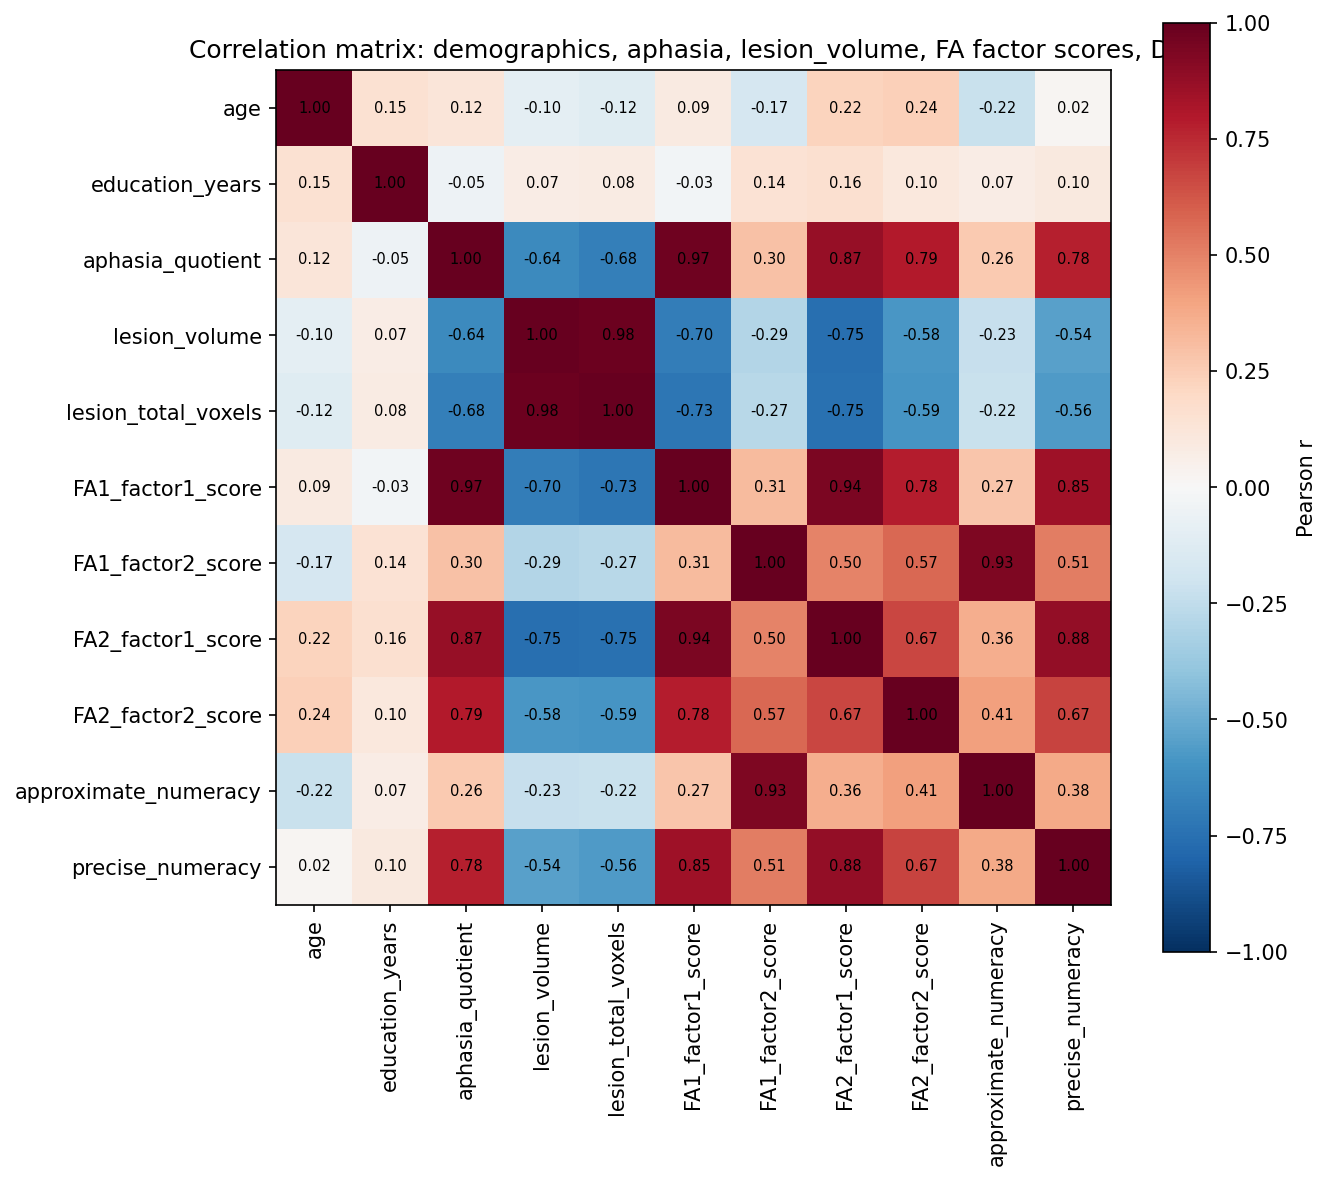

aphasia_quotient vs approximate_numeracy: 0.263
aphasia_quotient vs precise_numeracy:     0.778


In [15]:
corr_cols = ["age", "education_years", "aphasia_quotient", "lesion_volume", "lesion_total_voxels",
             "FA1_factor1_score", "FA1_factor2_score", "FA2_factor1_score", "FA2_factor2_score",
             "approximate_numeracy", "precise_numeracy"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, label="Pearson r")
ax.set_title("Correlation matrix: demographics, aphasia, lesion_volume, FA factor scores, DVs")
plt.tight_layout()
plt.show()

print("aphasia_quotient vs approximate_numeracy:", round(df["aphasia_quotient"].corr(df["approximate_numeracy"]), 3))
print("aphasia_quotient vs precise_numeracy:    ", round(df["aphasia_quotient"].corr(df["precise_numeracy"]), 3))

## What correlates with each numeracy DV? (excluding the circular FA factor scores)

Same idea, but the other direction: instead of a feature-feature matrix,
rank every candidate predictor (demographics, `aphasia_quotient`,
`lesion_volume`, and the prevalence-filtered lesion ROIs — affected in > 10
subjects, per the earlier filter) by its correlation with each DV
separately. This is the "predicting numeracy performance" view — a first,
purely univariate look at what might matter before any actual modeling.

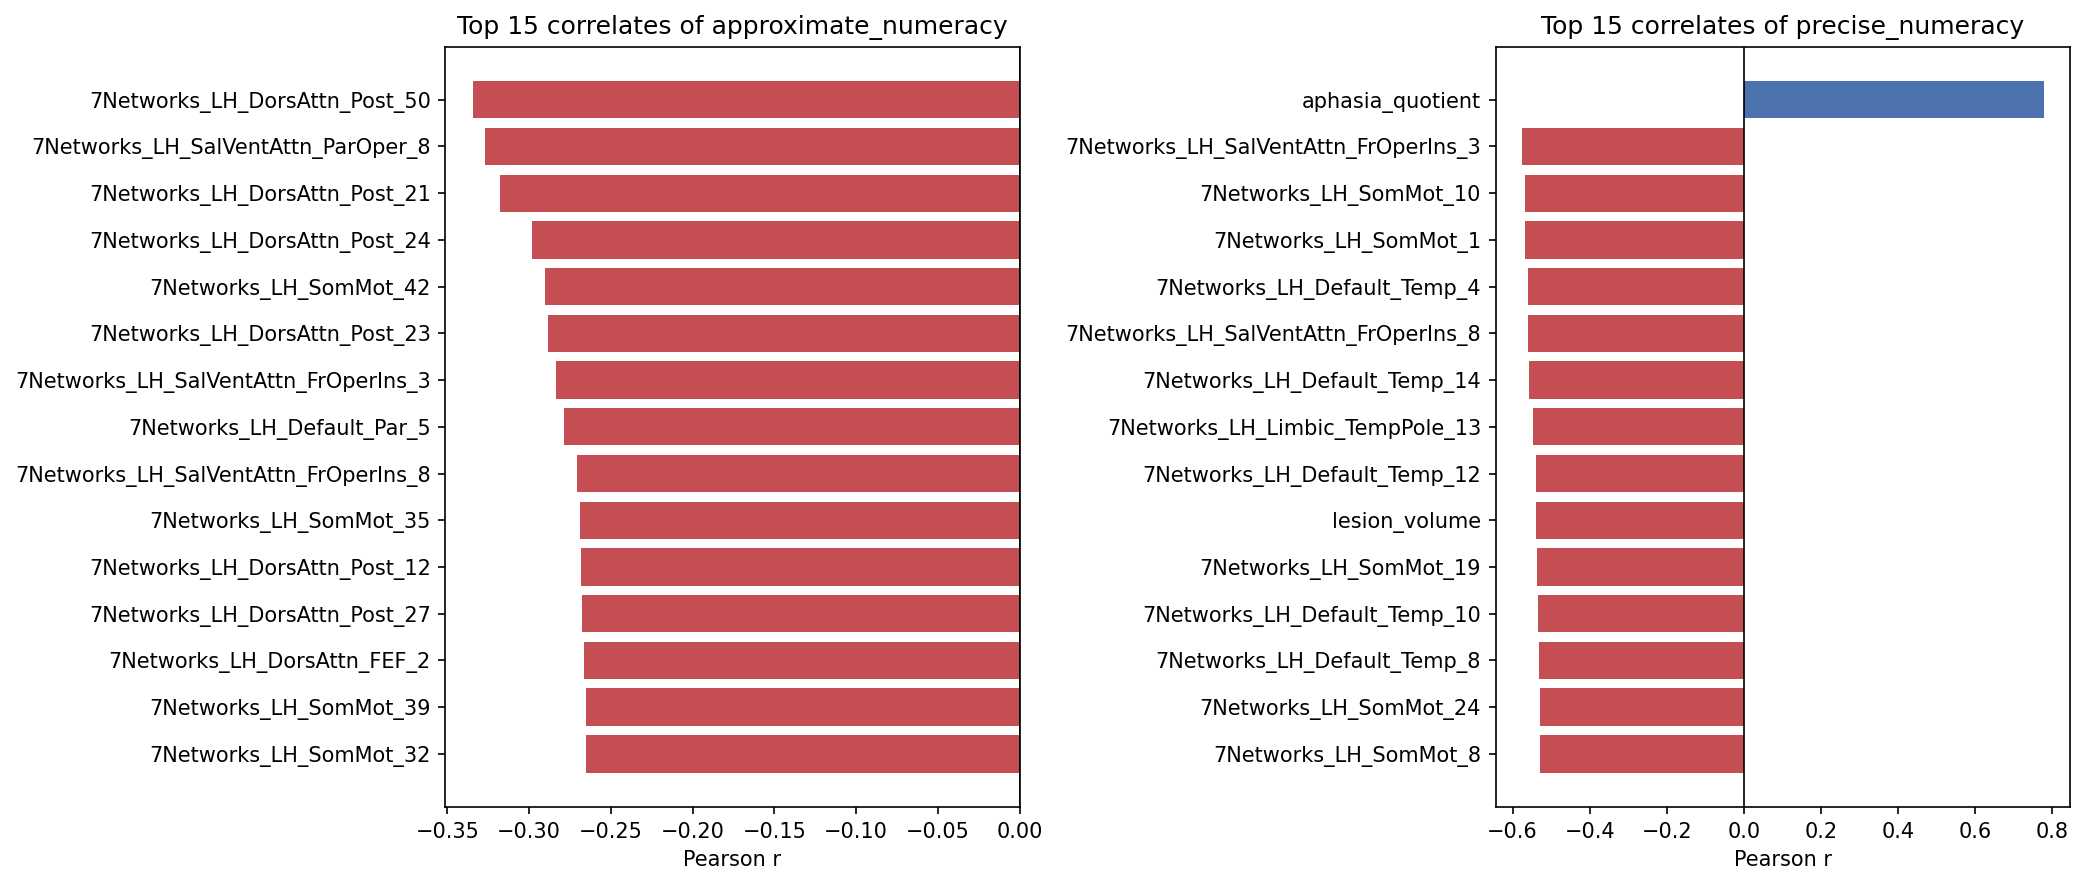

In [16]:
n_affected_per_roi = (df[lesion_ratio_cols] > 0).sum(axis=0)  # recomputed locally (defined again, in full, later)
candidate_cols = ["age", "education_years", "aphasia_quotient", "lesion_volume"] + \
    [c for c in lesion_ratio_cols if n_affected_per_roi[c] > 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, dv in zip(axes, ["approximate_numeracy", "precise_numeracy"]):
    corrs = df[candidate_cols].corrwith(df[dv]).dropna().sort_values(key=lambda s: s.abs(), ascending=False)
    top15 = corrs.head(15)
    label_map = {c: specs[c]["label"].replace("Lesion overlap: ", "") for c in lesion_ratio_cols if c in specs}
    labels = [label_map.get(c, c) for c in top15.index]
    colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top15.values]
    ax.barh(labels[::-1], top15.values[::-1], color=colors[::-1])
    ax.set_xlabel("Pearson r")
    ax.set_title(f"Top 15 correlates of {dv}")
    ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## How much to inspect with 1168 lesion columns?

Not column-by-column - that's not tractable or useful. What matters is how many of them carry any signal at all *in this specific 105-subject cohort*: a parcel that's never lesioned in anyone is a constant column (zero variance), which is useless (and often actively harmful - e.g. it breaks z-scoring, since dividing by std=0). Checking that distribution once, in aggregate, tells you
everything column-by-column inspection would.

Out of 1168 total lesion ROI columns:
  affected in >  0 subjects:  495 columns (42%)
  affected in >  1 subjects:  417 columns (36%)
  affected in >  5 subjects:  309 columns (26%)
  affected in > 10 subjects:  187 columns (16%)
  affected in > 20 subjects:   52 columns (4%)


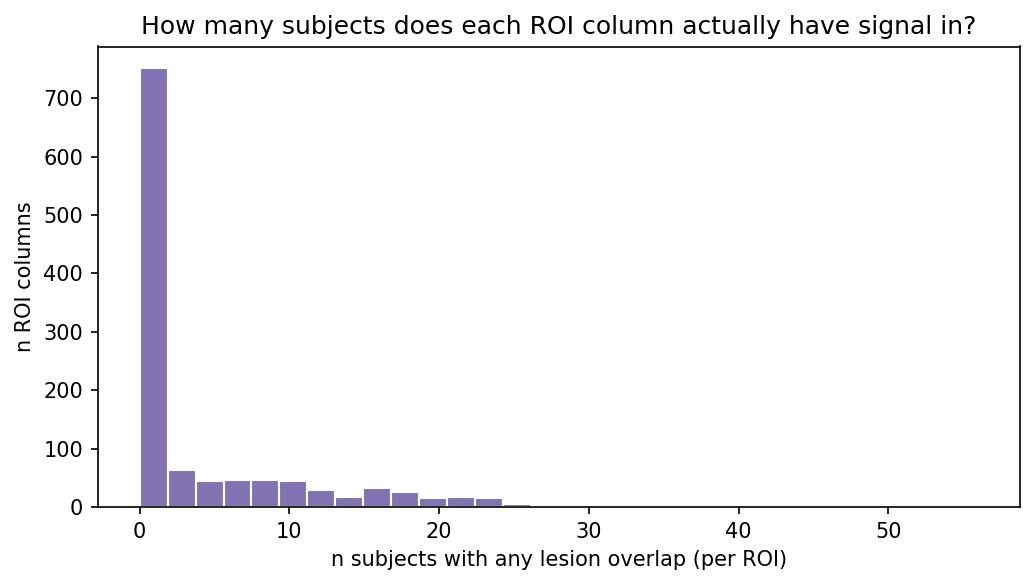

In [17]:
n_subjects_affected = (df[lesion_ratio_cols] > 0).sum(axis=0)  # per-ROI, across all 105 subjects

thresholds = [0, 1, 5, 10, 20]
print(f"Out of {len(lesion_ratio_cols)} total lesion ROI columns:")
for t in thresholds:
    n = (n_subjects_affected > t).sum()
    print(f"  affected in > {t:>2} subjects: {n:4d} columns ({100*n/len(lesion_ratio_cols):.0f}%)")

plt.figure(figsize=(7, 4))
plt.hist(n_subjects_affected, bins=30, color="#8172B2", edgecolor="white")
plt.xlabel("n subjects with any lesion overlap (per ROI)")
plt.ylabel("n ROI columns")
plt.title("How many subjects does each ROI column actually have signal in?")
plt.tight_layout()
plt.show()

## Should you use all 1168 lesion features, or select a subset?

With 105 subjects and up to 1168 lesion columns, you have far more features
than observations (*p* ≫ *n*) - a plain linear model fit on all of them will
overfit essentially by construction, and the zero-variance columns above
would break z-scoring outright. Recommendation: **don't hand-pick individual
ROIs** (that invites cherry-picking); instead pick one systematic strategy
and let it do the narrowing:

- **Prevalence filter** (simplest): drop ROIs affected in fewer than some
  minimum number of subjects (e.g. >10, leaving the 217 shown above) before
  modeling at all. Cheap, and removes the columns that are mathematically
  guaranteed to be useless in this cohort regardless of downstream method.
- **Regularization** (LASSO / ElasticNet): keep all (or prevalence-filtered)
  columns and let an L1-penalized model zero out the uninformative ones
  during fitting. Standard choice for *p* ≫ *n* tabular data, and it selects
  jointly rather than one column at a time.
- **Coarser aggregation**: collapse to network/structure-level lesion load
  (e.g. the 7 Yeo cortical networks, or per-structure Tian/Nettekoven groups)
  instead of per-parcel. Trades resolution for a *p* that's actually
  manageable relative to *n* = 105, at the cost of losing fine-grained
  localization.

These aren't mutually exclusive - prevalence-filter first regardless of what
you do next, since it's free and uncontroversial.

## Where does `validation/common/transforms.py` actually get used?

To be precise about what's wired up vs. what's just advice: **nothing in this
repo currently calls `transforms.py` automatically.** It's a small, reusable
module (`rank_int`, `flag_outliers_zscore`) that this notebook imports for
exploration - it is not part of `01_download_lesion_data.py` /
`02_build_processed_tables.py`, and there is no COMPASS-fitting step for
NUMERACY_STROKE yet (unlike AOMIC_ID1000, which has one at
`pipeline/04_run_compass.py`).

So "using transformed variables" means: whenever you (or a future
`build_compass_inputs.py`-equivalent for this dataset) load
`data/processed/_all_subjects_features.csv` to actually fit/evaluate a model,
that loading script is where you'd `from validation.common.transforms import
rank_int, flag_outliers_zscore` and apply them - fit on the training split,
apply the same fitted transform to validation/test. The processed CSVs
themselves stay raw on purpose, so every downstream use (including different
transform choices for different experiments) starts from the same untouched
source.

## Using the recommended transforms from `validation/common/transforms.py`

The four recommendations above (rank-INT / Yeo-Johnson / Yeo-Johnson / log)
are now built into `transforms.py` as `RECOMMENDED_TRANSFORM` +
`apply_recommended_transform(column, x, fitted_params=None)`, so you don't
have to re-derive or copy-paste any of this. Fit (pass `fitted_params=None`)
on your training split, then pass the returned `fitted_params` back in when
transforming validation/test with that same fitted lambda:

```python
from validation.common.transforms import apply_recommended_transform

train_t, params = apply_recommended_transform("precise_numeracy", train_df["precise_numeracy"])
test_t, _ = apply_recommended_transform("precise_numeracy", test_df["precise_numeracy"], fitted_params=params)
```

`rank_int` and `log` ignore `fitted_params` (they have nothing to fit); only
`yeojohnson` actually uses the stored lambda.

In [18]:
from validation.common.transforms import RECOMMENDED_TRANSFORM, apply_recommended_transform

for col in RECOMMENDED_TRANSFORM:
    values = df[col].dropna()
    transformed, params = apply_recommended_transform(col, values)
    print(f"{col:22s} ({RECOMMENDED_TRANSFORM[col]:10s}): "
          f"raw skew={stats.skew(values):+.2f} -> transformed skew={stats.skew(transformed):+.2f}"
          + (f", fitted lambda={params['lmbda']:.3f}" if "lmbda" in params else ""))

aphasia_quotient       (rank_int  ): raw skew=-3.67 -> transformed skew=-0.12
approximate_numeracy   (yeojohnson): raw skew=-1.20 -> transformed skew=-0.04, fitted lambda=1.653
precise_numeracy       (yeojohnson): raw skew=-2.95 -> transformed skew=-0.45, fitted lambda=3.556
lesion_volume          (log       ): raw skew=+2.78 -> transformed skew=-0.05
